In [40]:
import math
import numpy as np
import scipy.stats as ss
import scipy.linalg as sl
import matplotlib.pyplot as plt

rng = np.random.default_rng(30)

Task 7

The mean lifetime is: 260.6557758370406
The standard deviation is: 182.45314081295507
Proportion of women whose cancer eventually reappears locally: 0.43


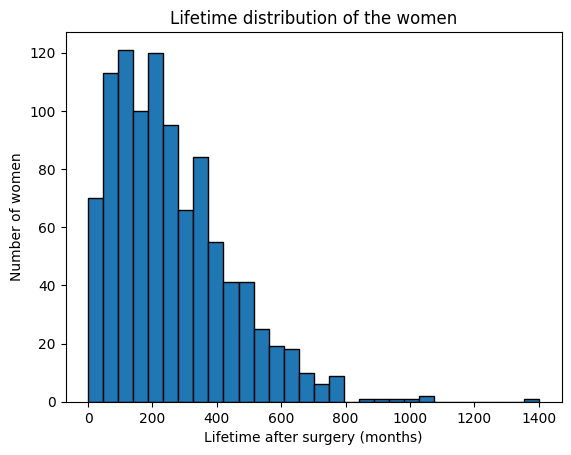

In [41]:
rng = np.random.default_rng(30)

Q = np.array([[-0.0085, 0.005, 0.0025, 0,     0.001],
              [0,      -0.014, 0.005,  0.004, 0.005],
              [0,       0,    -0.008,  0.003, 0.005],
              [0,       0,     0,     -0.009, 0.009],
              [0,       0,     0,      0,     0]])

n = 1000
death = 4
reappar = 2
lifetimes = np.zeros(n)
has_reappeared = np.zeros(n)

for i in range(n):
    t = 0
    state = 0

    while state != death:
        t += rng.exponential(-1/Q[state,state])
        
        proposals = [0,1,2,3,4]
        proposals.pop(state)

        probability = - (Q[state,proposals]) / (Q[state,state])
        state = rng.choice(a=proposals, p=probability)

        if (state == reappar and t > 30.5):
            has_reappeared[i] = 1
        
        if (state == death):
            lifetimes[i] = t
            break

print('The mean lifetime is:', np.mean(lifetimes))
print('The standard deviation is:', np.std(lifetimes))
proportion_reappear = sum(has_reappeared) / n
print('Proportion of women whose cancer eventually reappears locally:', proportion_reappear)

plt.hist(lifetimes, bins=30, edgecolor='black')
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Number of women")
plt.title("Lifetime distribution of the women")
plt.show()

Task 8

Chi-square: 33.80449780282977
p-value: 0.24648872466249933


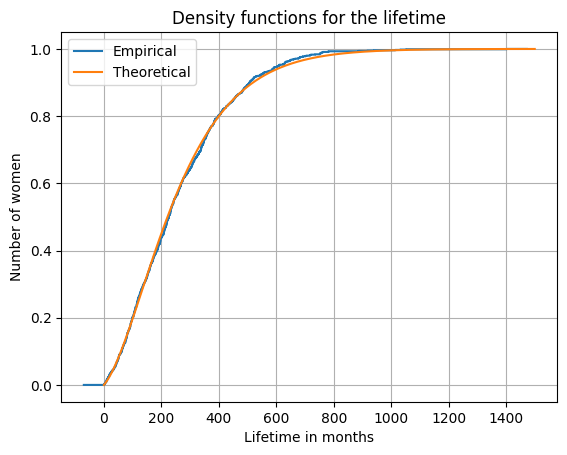

In [42]:
rng = np.random.default_rng(30)

p0 = np.array([1, 0, 0, 0])
Qs = Q[:4, :4]
T = np.arange(0,1500,1)

def F_T(p0, Qs, t):
    return 1 - p0 @ sl.expm(Qs*t) @ np.ones(4)

FT = np.array([F_T(p0, Qs, t) for t in range(len(T))])

# chi-square test
bins = np.arange(0, 1501, 50)
obs_counts, _ = np.histogram(lifetimes, bins=bins)
cdf_vals = np.array([F_T(p0, Qs, t) for t in bins])
exp_probs = np.diff(cdf_vals)
exp_probs = exp_probs / exp_probs.sum()
exp_counts = exp_probs * obs_counts.sum()
mask = exp_counts > 0
chi2, p = ss.chisquare(obs_counts[mask], exp_counts[mask])
print("Chi-square:", chi2)
print("p-value:", p)

ecdf = ss.ecdf(lifetimes)

ecdf.cdf.plot(label='Empirical')
plt.plot(T, FT, label='Theoretical')
plt.ylabel("Number of women")
plt.xlabel("Lifetime in months")
plt.title('Density functions for the lifetime')
plt.legend()
plt.grid()
plt.show()


Task 9

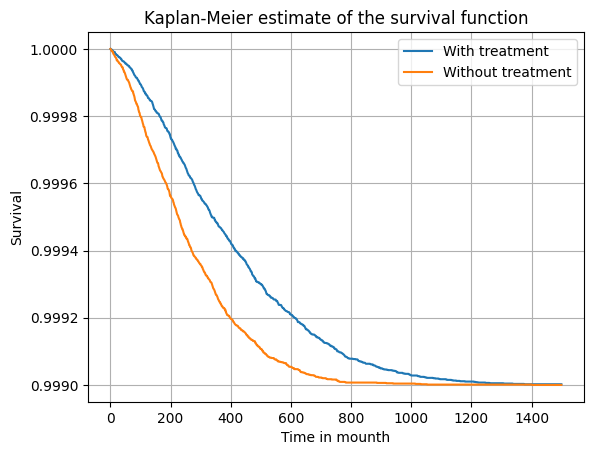

In [43]:
rng = np.random.default_rng(30)

Q2 = np.array([[0, 0.0025, 0.00125, 0,     0.001],
               [0, 0,      0,       0.002, 0.005],
               [0, 0,      0,       0.003, 0.005],
               [0, 0,      0,       0,     0.009],
               [0, 0,      0,       0,     0]])
for i in range(4):
    Q2[i,i] = - np.sum(Q2[i])

n = 1000
lifetimes2 = np.zeros(n)

for i in range(n):
    t = 0
    state = 0

    while state != death:
        t += rng.exponential(-1/Q2[state,state])

        proposals = [0,1,2,3,4]
        proposals.pop(state)

        probability = - (Q[state,proposals]) / (Q[state,state])
        state = rng.choice(a=proposals, p=probability)
        
        if (state == death):
            lifetimes2[i] = t
            break

ecdf2 = ss.ecdf(lifetimes2)

life2 = lambda t: (n - ecdf2.cdf.evaluate(t)) / n
life = lambda t: (n - ecdf.cdf.evaluate(t)) / n

plt.plot(T, life2(T), label='With treatment')
plt.plot(T, life(T), label='Without treatment')
plt.ylabel("Survival")
plt.xlabel("Time in mounth")
plt.title('Kaplan-Meier estimate of the survival function')
plt.legend()
plt.grid()
plt.show()

Task 10

In [44]:
ss.logrank(lifetimes, lifetimes2).pvalue

np.float64(1.7129533515856225e-40)